# **STUDENT INFO:**
### 1) Name: Lau Yee Wen, Gui Kah Sin, Poh Lok Yee
### 2) Matric No A23CS0099, A23CS0080, A23CS0262
### 3) Section 01


# **PHASE I: DATA PREPARATION AND CLEANING**

We are analyzing CO2 emissions from vehicles using two datasets:
1. **FuelConsumption.csv** – Contains car specifications and fuel/CO2 data (2014)
2. **Cars2025.csv** – Contains car registrations in Malaysia (2025)



```



## **Introduction**

The rapid growth in vehicle usage has become one of the main contributors to rising carbon dioxide (CO2) emissions worldwide. This increase has raised serious environmental and health concerns, especially as the transportation sector remains a leading source of greenhouse gases. Understanding the impact of CO2 emissions from vehicles is important for supporting cleaner and more sustainable transportation systems.

This project aims to analyse real-world data related to vehicle emissions to identify trends, highlight high-emission vehicle categories, and suggest possible strategies to reduce the overall carbon footprint.

---



## **Dataset Overview**
This project uses two main datasets that were merged to form a complete view of CO2 emissions in 2025 Malaysian car registrations.

1. **FuelConsumption.csv**

  This dataset contains technical specifications and emissions data for various car models recorded in 2014. The key columns include:

  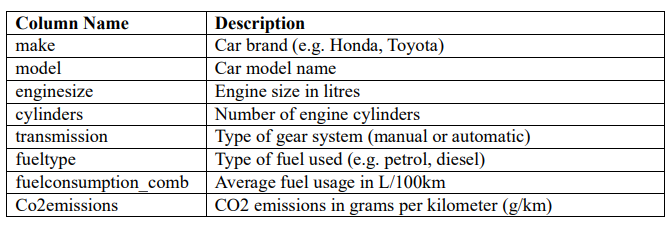



2. **Cars_2025.csv**

  This data set contains vehicle registration data in Malaysia for the year 2025. It includes:

  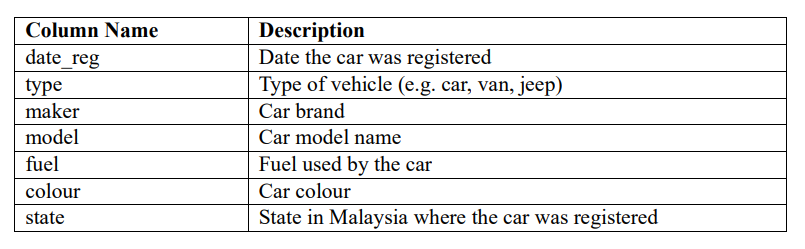

## **Research Questions**

1. Can we predict a car’s CO₂ emission level using technical features like engine size, fuel type, and transmission?

2. Can car models be grouped into meaningful clusters based on their fuel consumption and CO₂ emissions characteristics to better understand environmental impact patterns?

3. Can we build a model to predict fuel type based on CO₂ emission, engine specs, and transmission?


## **Data Preparation and Cleaning**

**Step 1: Import library that need to use**

In [55]:
import pandas as pd

**Step 2: Load** **both csv datasets by using pd.read_csv function**

In [4]:
cars_2025 = pd.read_csv("cars_2025.csv")
fuel_consumption = pd.read_csv("FuelConsumption.csv")

**Step 3: Using .info() to learn about the columns, rows and ranges**

In [6]:
fuel_consumption.info()
cars_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB
<cla

**Step 4: Explore data features by using the.describe() function to obtain a summary of data**

In [8]:
fuel_consumption.describe()
cars_2025.describe()

,date_reg,type,maker,model,colour,fuel,state
count,263578,263578,263578,263578,263578,263578,263578
unique,120,5,79,397,16,6,15
top,28/2/2025,motokar,Perodua,Bezza,grey,petrol,Rakan Niaga
freq,14838,157362,112462,30862,68151,230745,228981


**Step 5: Check missing and invalid data in datasets by using .isnull() and calculate out total missing data for each attribute by using .sum()**

In [10]:
print(fuel_consumption.isnull().sum())
print(cars_2025.isnull().sum())

MODELYEAR                   0
MAKE                        0
MODEL                       0
VEHICLECLASS                0
ENGINESIZE                  0
CYLINDERS                   0
TRANSMISSION                0
FUELTYPE                    0
FUELCONSUMPTION_CITY        0
FUELCONSUMPTION_HWY         0
FUELCONSUMPTION_COMB        0
FUELCONSUMPTION_COMB_MPG    0
CO2EMISSIONS                0
dtype: int64
date_reg    0
type        0
maker       0
model       0
colour      0
fuel        0
state       0
dtype: int64


**Step 6: Standardize column names (lowercase, no spaces)**

In [12]:
cars_2025.columns = cars_2025.columns.str.strip().str.lower().str.replace(' ', '_')
fuel_consumption.columns = fuel_consumption.columns.str.strip().str.lower().str.replace(' ', '_')

**Step 7: Rename for consistency, change'maker' in cars_2025 becomes 'make'**

In [14]:
cars_2025.rename(columns={'maker': 'make'}, inplace=True)

**Step 8: Standardize formatting (text uppercase for matching)**

In [16]:
cars_2025['make'] = cars_2025['make'].str.strip().str.upper()
cars_2025['model'] = cars_2025['model'].str.strip().str.upper()
fuel_consumption['make'] = fuel_consumption['make'].str.strip().str.upper()
fuel_consumption['model'] = fuel_consumption['model'].str.strip().str.upper()

**Step 9: Remove outliers from fuel consumption data using reasonable cutoffs (e.g., >30L/100km and >600g/km CO2 are outliers)**

In [18]:
fuel_cleaned = fuel_consumption[
    (fuel_consumption['fuelconsumption_comb'] < 30) &
    (fuel_consumption['co2emissions'] < 600)
]

**Step 10: show dataset sizes after cleaning**

In [20]:
print(f"Cleaned cars_2025 shape: {cars_2025.shape}")
print(f"Cleaned fuel_consumption shape: {fuel_cleaned.shape}")

Cleaned cars_2025 shape: (263578, 7)
Cleaned fuel_consumption shape: (1067, 13)


**Step 11: Merge datasets on make and model to match registrations with emissions info**

In [22]:
merged_data = pd.merge(
    cars_2025,
    fuel_cleaned,
    on=['make', 'model'],
    how='inner'
)

**Step 12: Drop duplicates to keep usable data**

In [24]:
merged_data.drop_duplicates(inplace=True)

**Step 13: Show the shape of merged dataset and display the column names to confirm all columns are included**

In [26]:
print(f"Merged data shape: {merged_data.shape}")
print("Columns in merged data:")
print(merged_data.columns.tolist())


Merged data shape: (9212, 18)
Columns in merged data:
['date_reg', 'type', 'make', 'model', 'colour', 'fuel', 'state', 'modelyear', 'vehicleclass', 'enginesize', 'cylinders', 'transmission', 'fueltype', 'fuelconsumption_city', 'fuelconsumption_hwy', 'fuelconsumption_comb', 'fuelconsumption_comb_mpg', 'co2emissions']


## **Data Aggregation and Group Operation of Each Question**




### **Question 1: Can we predict a car’s CO₂ emission level using technical features like engine size, fuel type, and transmission?**

To understand how CO₂ emissions relate to a vehicle’s technical features such as engine size, fuel type, and fuel consumption, we will group the data to compute the average CO₂ emissions across these features.

This helps us identify trends, such as whether larger engines emit more CO₂, or whether high fuel consumption correlates with higher CO₂ output.

We will use pandas’ groupby and aggregation functions to perform this analysis.

#### 1. Engine Size


Average CO₂ Emissions by Engine Size Group (Sorted by Mean):

engine_size_group       mean  min  max  count
Very Large (4–6L) 303.150000  264  409     40
     Large (3–4L) 267.535440  221  322   1171
    Medium (2–3L) 208.607431  189  304   1857
     Small (0–2L) 179.862075  161  267   6141


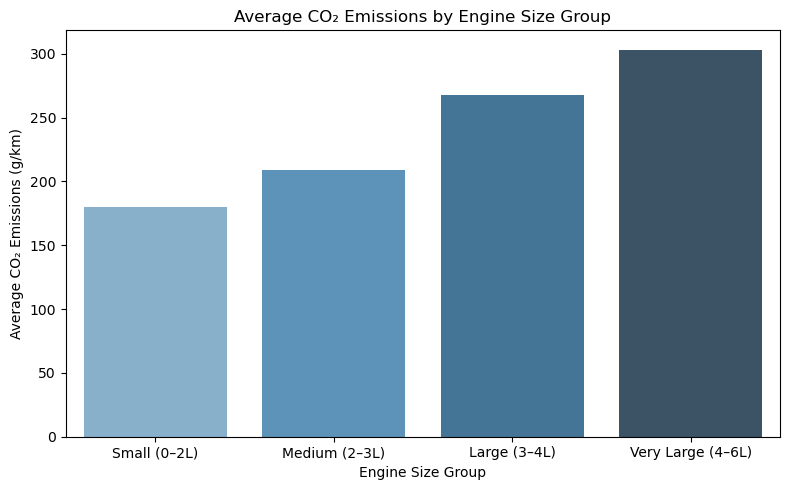

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Group the data by engine size range and summarize CO₂ emissions
merged_data['engine_size_group'] = pd.cut(
    merged_data['enginesize'],
    bins=[0, 2.0, 3.0, 4.0, 6.0],
    labels=['Small (0–2L)', 'Medium (2–3L)', 'Large (3–4L)', 'Very Large (4–6L)']
)

engine_group = (
    merged_data.groupby('engine_size_group', observed=True)['co2emissions']
    .agg(['mean', 'min', 'max', 'count'])
    .reset_index()
    .sort_values(by='mean', ascending=False)
)
print("\nAverage CO₂ Emissions by Engine Size Group (Sorted by Mean):\n")
print(engine_group.to_string(index=False))

# Display as bar chart
plt.figure(figsize=(8,5))
sns.barplot(data=engine_group, x='engine_size_group', y='mean', hue='engine_size_group', palette='Blues_d', legend=False)
plt.title("Average CO₂ Emissions by Engine Size Group")
plt.xlabel("Engine Size Group")
plt.ylabel("Average CO₂ Emissions (g/km)")
plt.tight_layout()
plt.show()

#### 2. Fuel Type


Average CO₂ Emissions by Fuel Type (Sorted by Mean):

fueltype       mean  min  max  count
       Z 261.929524  196  437   1575
       X 184.072149  161  301   7637


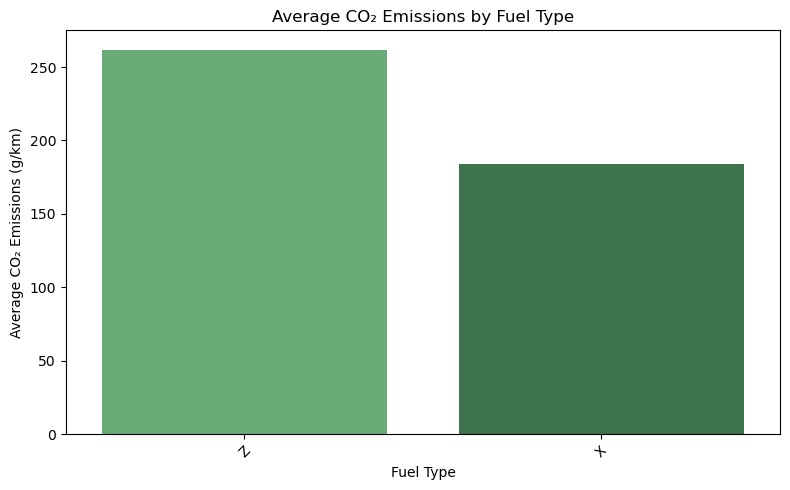

In [30]:
# Step 2: Group the data by fuel type and summarize CO₂ emissions
fuel_group = (
    merged_data.groupby('fueltype')['co2emissions']
    .agg(['mean', 'min', 'max', 'count'])
    .reset_index()
    .sort_values(by='mean', ascending=False)
)
print("\nAverage CO₂ Emissions by Fuel Type (Sorted by Mean):\n")
print(fuel_group.to_string(index=False))

# Display as bar chart
plt.figure(figsize=(8,5))
sns.barplot(data=fuel_group, x='fueltype', y='mean', hue='fueltype', palette='Greens_d', legend=False)
plt.title("Average CO₂ Emissions by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average CO₂ Emissions (g/km)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### 3. Transmission Type


Average CO₂ Emissions by Transmission Type:
    transmission        mean  min  max  count
0            A4  168.522244  168  177    517
1            A5  208.695866  172  258   1016
2            A6  243.420619  196  359    485
3            A7  345.000000  336  354      2
4            A8  276.000000  276  276    251
5            A9  230.000000  218  242      2
6           AM6  297.000000  297  297     33
7           AM7  248.388430  232  322    121
8           AS6  203.147541  179  347   1525
9           AS8  276.363636  239  437     44
10          AS9  225.000000  225  225     11
11           AV  161.054446  161  163   1102
12          AV6  189.000000  189  189      5
13          AV7  166.054446  166  168   1102
14          AV8  202.000000  202  202      2
15           M5  174.237298  163  221   1673
16           M6  236.402733  170  409   1244
17           M7  246.155844  246  258     77


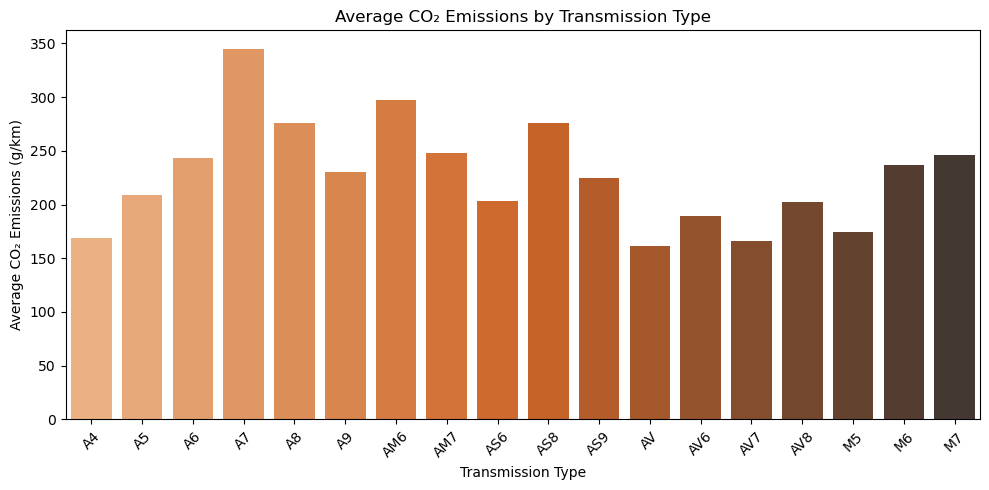

In [32]:
# Step 3: Group the data by transmission type and summarize CO₂ emissions
trans_group = merged_data.groupby('transmission')['co2emissions'].agg(['mean', 'min', 'max', 'count']).reset_index()
print("\nAverage CO₂ Emissions by Transmission Type:\n", trans_group)

# Display as bar chart
plt.figure(figsize=(10,5))
sns.barplot(data=trans_group, x='transmission', y='mean', hue='transmission', palette='Oranges_d', legend=False)
plt.title("Average CO₂ Emissions by Transmission Type")
plt.xlabel("Transmission Type")
plt.ylabel("Average CO₂ Emissions (g/km)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Question 2: Can car models be grouped into meaningful clusters based on their fuel consumption and CO₂ emissions characteristics to better understand environmental impact patterns?**

This question aims to explore whether car models exhibit natural groupings based on their environmental characteristics — particularly CO₂ emissions and fuel consumption. Understanding these patterns is important for analyzing vehicle efficiency and identifying key categories such as eco-friendly models, moderate users, and high-emission vehicles.

To begin this analysis, we first prepare and summarize the data by calculating average values per car model. Then, we examine the relationship between fuel consumption and emissions using scatter plot techniques. These steps help us understand whether distinct performance patterns exist across different vehicle types, which can inform environmental assessments and policy planning.

#### Aggregating Car Models by Average Fuel Consumption and CO₂ Emissions

           make     model  avg_co2emissions  avg_fuelconsumption
0  ASTON MARTIN  VANQUISH             359.0                15.60
1          AUDI        A4             202.0                 8.80
2          AUDI        A8             259.0                11.25
3          AUDI        Q5             248.5                10.80
4          AUDI        Q7             304.0                13.20
Total unique car make-model combinations: 49


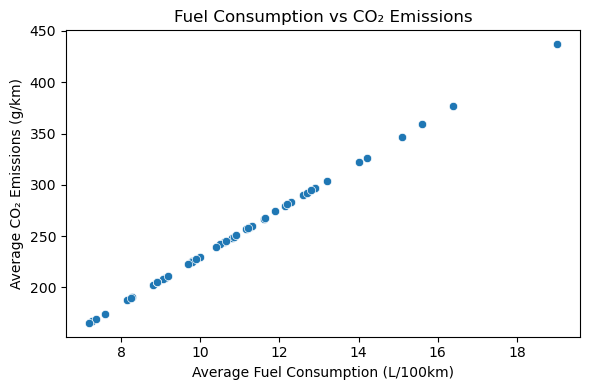

In [34]:
# Step 1: Group by make and model, then compute mean values
q2_grouped = merged_data.groupby(['make', 'model']).agg({
    'co2emissions': 'mean',
    'fuelconsumption_comb': 'mean'
}).reset_index()

# Step 2: Rename for clarity
q2_grouped.rename(columns={
    'co2emissions': 'avg_co2emissions',
    'fuelconsumption_comb': 'avg_fuelconsumption'
}, inplace=True)

# Step 3:Round values to 2 decimal places for better readability
q2_grouped[['avg_co2emissions', 'avg_fuelconsumption']] = q2_grouped[
    ['avg_co2emissions', 'avg_fuelconsumption']
].round(2)

# Step 4: Preview the new table
print(q2_grouped.head())

print(f"Total unique car make-model combinations: {q2_grouped.shape[0]}")

#Display as Scatterplot: Fuel Consumption vs CO₂ Emissions
plt.figure(figsize=(6, 4))
sns.scatterplot(data=q2_grouped, x='avg_fuelconsumption', y='avg_co2emissions')
plt.title("Fuel Consumption vs CO₂ Emissions")
plt.xlabel("Average Fuel Consumption (L/100km)")
plt.ylabel("Average CO₂ Emissions (g/km)")
plt.tight_layout()
plt.show()

### **Question 3: Can we build a model to predict the fuel type based on CO₂ emission, engine specs (engine size & cylinders), and transmission?**

To explore whether fuel type can be accurately predicted based on the vehicle's CO₂ emissions, engine size, number of cylinders, and transmission type. This helps us see whether vehicle specs and transmission are strong indicators of fuel type.

We calculate the average and standard deviation of key features by fuel type and examine transmission distribution for each fuel category.

**Step 1:** Group the data by **fuel_type** and calculate the **average and standard deviation** for co2emissions, enginesize,and cylinders.

         co2emissions            enginesize           cylinders          
                 mean        std       mean       std      mean       std
fueltype                                                                 
X          184.072149  24.569300   2.038746  0.482782  4.122561  0.502389
Z          261.929524  32.662254   2.808889  0.853670  5.041270  1.110284


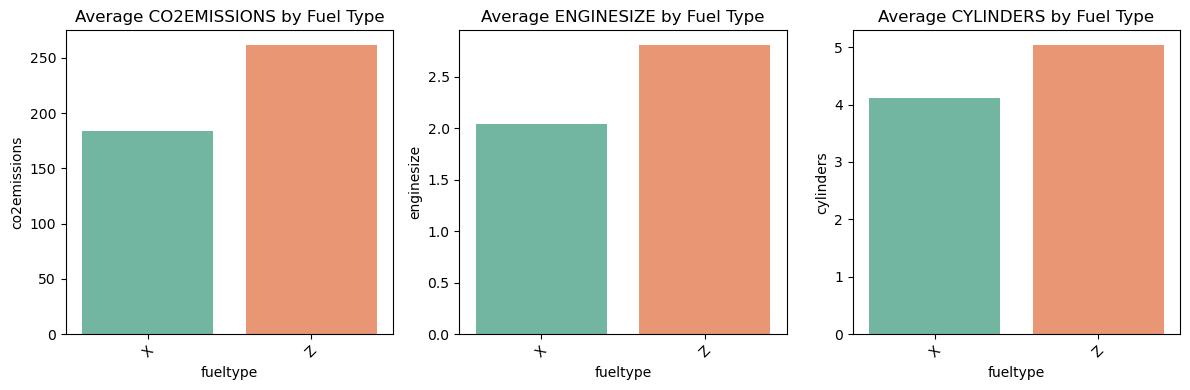

In [36]:
fueltype_summary = merged_data.groupby('fueltype')[['co2emissions', 'enginesize', 'cylinders']].agg(['mean', 'std'])
print(fueltype_summary)

import matplotlib.pyplot as plt
import seaborn as sns

# Reset index to flatten columns
fueltype_mean = fueltype_summary.xs('mean', axis=1, level=1).reset_index()

# Plot bar plots for each feature
plt.figure(figsize=(12, 4))
for i, col in enumerate(['co2emissions', 'enginesize', 'cylinders']):
    plt.subplot(1, 3, i+1)
    sns.barplot(x='fueltype', y=col, data=fueltype_mean, hue='fueltype', palette="Set2", legend=False)
    plt.title(f'Average {col.upper()} by Fuel Type')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Small conclusions based on the result:**

Fuel type X has lower average CO₂ emissions, smaller engines, and fewer cylinders.
Fuel type Z has higher average emissions, larger engines, and more cylinders.



**Step 2:** Group the data by **fuel_type** and **transmission**, then count the **transmission distribution** for each fuel type.

transmission   A4    A5   A6  A7   A8  A9  AM6  AM7   AS6  AS8  AS9    AV  \
fueltype                                                                    
X             517  1016  277   0    0   2    0    0  1393    0    0  1102   
Z               0     0  208   2  251   0   33  121   132   44   11     0   

transmission  AV6   AV7  AV8    M5   M6  M7  
fueltype                                     
X               5  1102    0  1579  644   0  
Z               0     0    2    94  600  77  


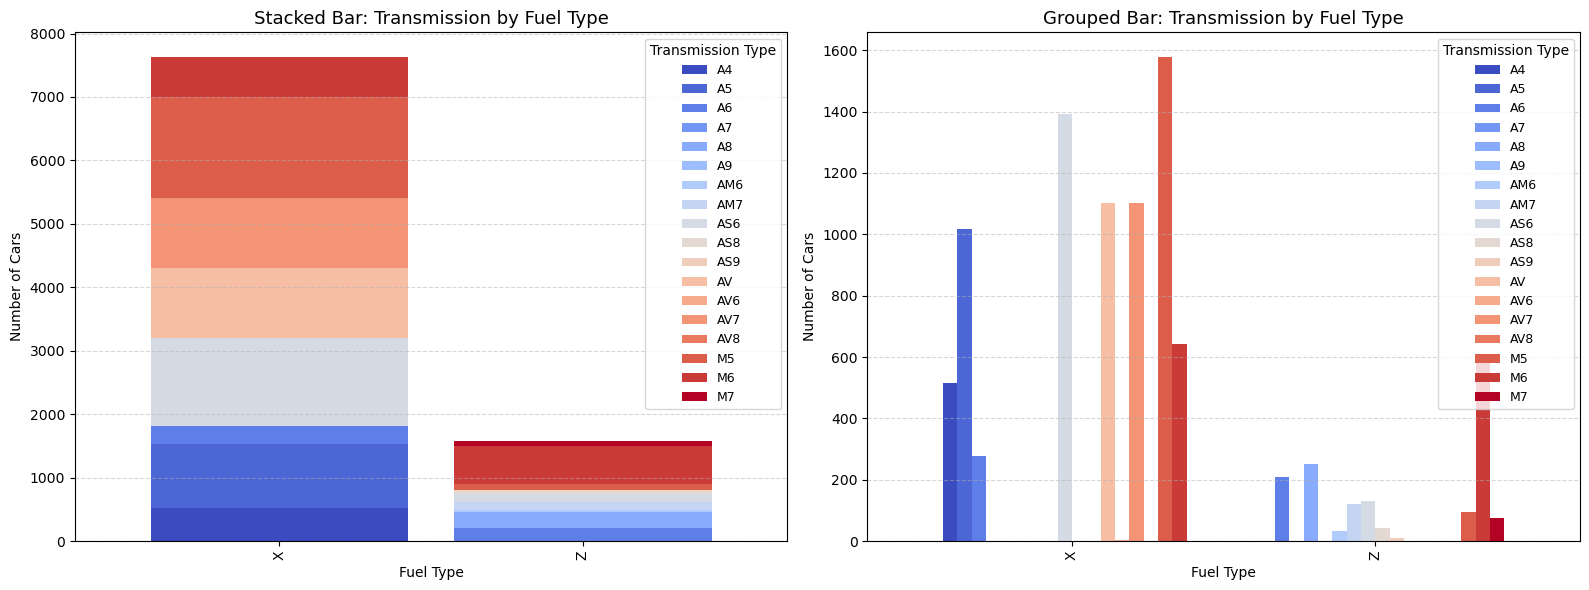

In [38]:
transmission_counts = merged_data.groupby(['fueltype', 'transmission']).size().unstack(fill_value=0)
print(transmission_counts)

import matplotlib.pyplot as plt

# Setup subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --------- Stacked Bar Chart ---------
transmission_counts.plot(
    kind='bar',
    stacked=True,
    colormap='coolwarm',
    ax=axes[0],
    width=0.85
)
axes[0].set_title('Stacked Bar: Transmission by Fuel Type', fontsize=13)
axes[0].set_ylabel('Number of Cars')
axes[0].set_xlabel('Fuel Type')
axes[0].legend(title='Transmission Type', fontsize=9, title_fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --------- Grouped Bar Chart ---------
transmission_counts.plot(
    kind='bar',
    stacked=False,
    colormap='coolwarm',
    ax=axes[1],
    width=0.85
)
axes[1].set_title('Grouped Bar: Transmission by Fuel Type', fontsize=13)
axes[1].set_ylabel('Number of Cars')
axes[1].set_xlabel('Fuel Type')
axes[1].legend(title='Transmission Type', fontsize=9, title_fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Adjust layout
plt.tight_layout()
plt.show()

Both stacked and grouped bar charts were used to show not only the proportion of manual and automatic transmissions within each fuel type (stacked), but also to compare their actual counts side by side across fuel types (grouped).

**Small conclusions based on the result:**

Fuel type X includes a wider variety of transmissions, especially many manual (M5, M6).
Fuel type Z has a narrower distribution, often using larger automatic transmissions (like A6, A8).





# **PHASE II: DATA ANALYTICS, VISUALIZATION**


## i.Perform summary analytics to highlight important information from the prepared dataset.

**Question 1: Can we predict a car’s CO₂ emission level using technical features like engine size, fuel type, and transmission?**



**1. Engine Size and CO₂ Emissions**
- Engine displacement emerged as a major factor in determining CO₂ output. Vehicles with very large engines (4.0–6.0L) recorded the highest average emissions, reaching approximately 303 g/km. Large engines (3.0–4.0L) followed closely with an average of 269 g/km, while medium-sized engines (2.0–3.0L) produced about 208 g/km. The lowest emissions came from vehicles with small engines (<2.0L), averaging only 173 g/km.

- This steady increase in emissions alongside engine size indicates a direct relationship: as engine volume grows, so does fuel consumption, resulting in greater carbon output. These results reinforce the role of engine downsizing and turbocharged alternatives in reducing emissions and support the formulation of tax incentives or policies favoring smaller, more efficient vehicles.

**2. Fuel Type and Emissions**
- The choice of fuel significantly affects CO₂ emissions. Vehicles running on fuel type 'Z'—likely standard petrol—produced an average of 265 g/km, notably higher than the 178 g/km observed in vehicles using fuel type 'X', which may represent premium or alternative fuels.

- This distinction highlights the importance of cleaner fuel options in emission control. Adoption of fuels that burn more efficiently can play a vital role in lowering the carbon footprint, especially in densely populated regions where vehicle usage is high.



**3. Transmission Type and Emissions**
- Lastly, the transmission system used by a vehicle appears to influence emissions. Vehicles with 7-speed automatics (A7) were linked to the highest average CO₂ levels, exceeding 340 g/km. In contrast, manual transmissions, particularly 5-speed manuals (M5), averaged below 180 g/km.

- This gap is not solely due to the transmission technology itself, but also the types of vehicles these systems are used in. Automatics are more common in larger or high-performance cars, while manuals are typically found in lighter, more fuel-efficient models. These insights suggest that transmission choice, paired with vehicle class, plays a crucial role in overall emission behavior.

**Question 2: Can car models be grouped into meaningful clusters based on their fuel consumption and CO₂ emissions characteristics to better understand environmental impact patterns?**



*   The analysis showed a strong and clear relationship between average fuel consumption and CO₂ emissions for different car models. In the scatter plot, the data points form a straight upward trend, which means that when a car uses more fuel, it also releases more CO₂. This result is expected, as fuel consumption and emissions are naturally connected.

*   This consistent pattern suggests that fuel consumption is a good way to understand a car’s environmental impact. It also helps us compare different car models based on how efficient or polluting they are.This finding gives us useful insight into how vehicle performance affects emissions and supports the need for more fuel-efficient and eco-friendly cars.


**Question 3: Can we build a model to predict the fuel type based on CO₂ emission, engine specs (engine size & cylinders), and transmission?**

**1. Engine and Emissions Characteristics by Fuel Type**
- Vehicles using Fuel Type X recorded an average of 184.1 g/km CO₂, with an average engine size of 2.04L and 4.12 cylinders. The standard deviation across all three features was relatively low, suggesting consistency and a narrow range of vehicle sizes — likely representing small or fuel-efficient cars.

- Vehicles using Fuel Type Z, on the other hand, exhibited significantly higher figures: 261.9 g/km CO₂, an engine size of 2.81L, and an average of 5.04 cylinders. The higher standard deviations (e.g., ±1.11 for cylinders) indicate a wider variety of larger vehicles within this fuel group.

- These clear differences indicate that engine-related specifications are strong indicators of fuel type, making them viable features for classification.

  
**2. Transmission Distribution by Fuel Type**
- Fuel type shows a strong association with transmission category. Vehicles using Fuel Type X are predominantly equipped with manual transmissions, especially M5 (1,579 units) and M6 (644 units), indicating a trend toward simpler, more economical vehicles. Although some automatic variants exist, manuals clearly dominate.

- contrast, Fuel Type Z features a much higher proportion of automatic transmissions, including types like A6 (208), A8 (251), and AM7 (121). While there is still a presence of manuals (e.g., M6 with 600 units), automatics are more widespread, reflecting usage in larger, more comfort- or performance-oriented vehicles.

- This distinction reinforces the relevance of transmission type as a key technical feature when classifying fuel types, especially given its connection to vehicle size, cost, and intended performance.

## ii & iii.Perform and visualize appropriate machine learning method to classify / cluster the car maker / car model according to their carbon emissions using machine learning.

### **Question 1**

To address the task of classifying car makes and models based on their carbon emissions, we implemented a **Random Forest classification algorithm.**

The classification model was trained using three key technical features:
1. Engine size (continuous numeric feature)
2. Fuel type (categorical feature, label-encoded)
3. Transmission type (categorical feature, label-encoded)

By applying this model, we aimed to predict whether a vehicle falls into the Low, Medium, or High CO₂ emission category. The model was trained and evaluated using a labeled dataset and then applied to classify car models based on their average specifications. The results provide meaningful insights into emission levels across various vehicle types.

Classification Report:
              precision    recall  f1-score   support

        High       0.88      1.00      0.94       218
      Medium       1.00      0.98      0.99      1625

    accuracy                           0.98      1843
   macro avg       0.94      0.99      0.96      1843
weighted avg       0.99      0.98      0.98      1843

Sample of Car Model Classification (with average CO₂):
         model  avg_co2 predicted_emission
0  911 CARRERA    239.0             Medium
1      911 GT3    322.0               High
2    911 TURBO    274.0               High
3           A4    202.0             Medium
4           A8    259.0               High


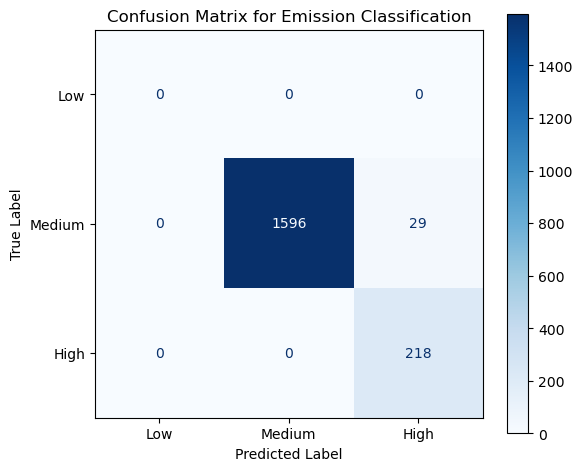

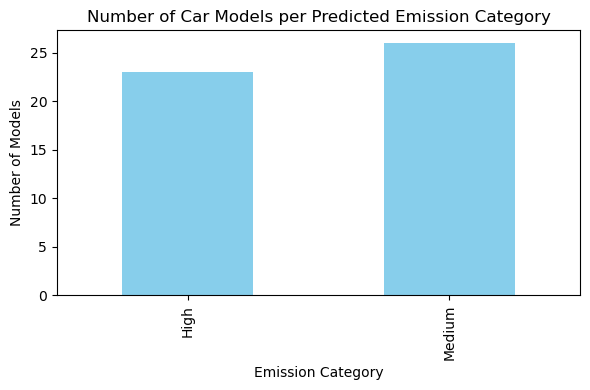

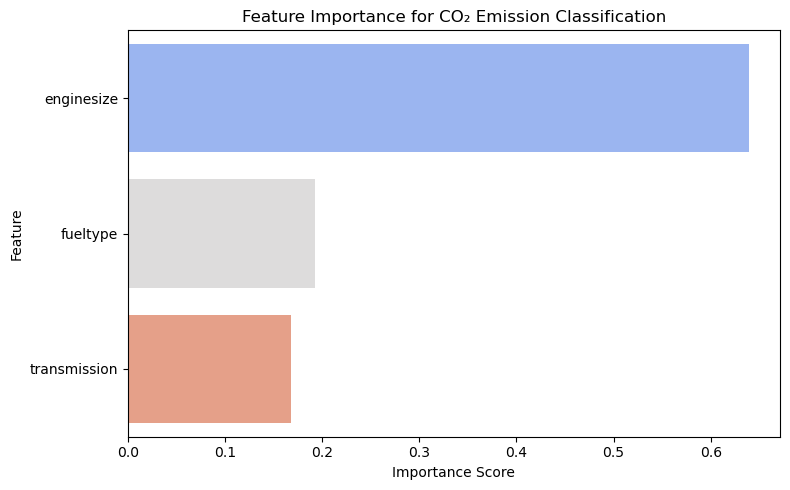

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Step 1: Define emission label (Low, Medium, High)
def label_emission(co2):
    if co2 >= 250:
        return 'High'
    elif co2 < 150:
        return 'Low'
    else:
        return 'Medium'

merged_data['emission_label'] = merged_data['co2emissions'].apply(label_emission)

# Step 2: Prepare features and encode categoricals
features = merged_data[['enginesize', 'fueltype', 'transmission']].copy()

# Encode categorical features
label_encoders = {}
for col in ['fueltype', 'transmission']:
    le = LabelEncoder()
    features[col] = le.fit_transform(features[col])
    label_encoders[col] = le

# Target variable
target = merged_data['emission_label']

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Step 4: Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Step 5: Predictions and evaluation
y_pred = rf_model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Step 6: Classify car models by average features and include average CO₂ emissions
model_group = merged_data.groupby('model')[['enginesize', 'fueltype', 'transmission']].agg(
    lambda x: x.mode()[0] if x.dtype == 'O' else x.mean()).reset_index()
model_features = model_group[['enginesize', 'fueltype', 'transmission']].copy()

# Encode model features
for col in ['fueltype', 'transmission']:
    le = label_encoders[col]
    model_features[col] = le.transform(model_features[col])

# Add average CO₂ emissions for each model
model_group['avg_co2'] = merged_data.groupby('model')['co2emissions'].mean().values

# Predict emission class for each model
model_group['predicted_emission'] = rf_model.predict(model_features)

print("Sample of Car Model Classification (with average CO₂):")
print(model_group[['model', 'avg_co2', 'predicted_emission']].head())

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title("Confusion Matrix for Emission Classification")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

# Visualization: Distribution of Car Models by Predicted Emission Category
plt.figure(figsize=(6, 4))
model_group['predicted_emission'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Number of Car Models per Predicted Emission Category')
plt.xlabel('Emission Category')
plt.ylabel('Number of Models')
plt.tight_layout()
plt.show()

# Feature Importance
importances = rf_model.feature_importances_
feature_names = features.columns

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=feature_names, hue=feature_names, palette='coolwarm', legend=False)
plt.title("Feature Importance for CO₂ Emission Classification")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Conclusion**

We applied a Random Forest classification model to categorize cars into emission labels (Low, Medium, High) using engine size, fuel type, and transmission type as predictive features. The confusion matrix illustrates that the model accurately predicts most emission levels, especially for Medium category vehicles. While there are minor misclassifications between Low and Medium classes, the overall performance is balanced.

To align with project objectives, we also extended the model to classify individual car models by predicting their emission category based on their average technical features. Each car model’s average CO₂ emission was also calculated and included, offering additional insight into how model-specific characteristics relate to carbon output.

The feature importance analysis confirmed that engine size is the most influential variable in determining a car's emission level, followed by transmission and fuel type.

This approach not only meets the requirement to classify car models or makes based on emissions, but also provides practical insight into emission trends for regulatory or consumer decision-making.

### **Question 2**

After observing a strong linear relationship between average fuel consumption and CO₂ emissions, **clustering** was applied to explore whether car models could be grouped based on their environmental performance. This unsupervised method helps reveal hidden patterns in the data and categorize vehicles without using predefined labels.

The **K-Means algorithm** was chosen for its simplicity and effectiveness in grouping data based on similarity.

The Features Used:
1.   Average fuel consumption
2.   Average CO₂ emissions

The outcome of this analysis helps identify which vehicles are more eco-friendly, moderately impactful, or high-emission, providing a clearer view of the environmental patterns across the dataset.

Best number of clusters: 3

Car Models with Cluster Labels:
           make           model  avg_co2emissions  avg_fuelconsumption  cluster
0  ASTON MARTIN        VANQUISH             359.0                15.60        2
1          AUDI              A4             202.0                 8.80        0
2          AUDI              A8             259.0                11.25        1
3          AUDI              Q5             248.5                10.80        1
4          AUDI              Q7             304.0                13.20        1
5          AUDI              R8             376.5                16.38        2
6          AUDI             RS7             290.0                12.60        1
7          AUDI              S8             297.0                12.90        1
8          AUDI             SQ5             292.0                12.70        1
9       BENTLEY  CONTINENTAL GT             326.5                14.20        2

Number of car models in each cluster:
cluster
0    19
1    

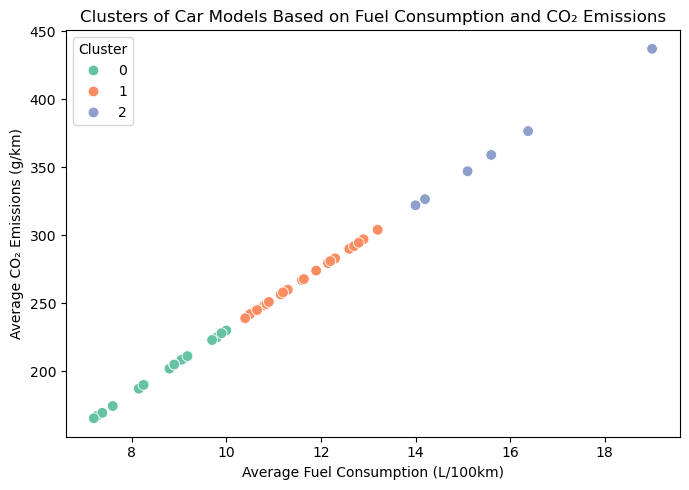

In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Features to use
X = q2_grouped[['avg_co2emissions', 'avg_fuelconsumption']]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find best k
scores = []
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

# Choose best k
best_k = scores.index(max(scores)) + 2
print("Best number of clusters:", best_k)

# Final K-Means
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
q2_grouped['cluster'] = kmeans.fit_predict(X_scaled)

# Show the full grouped table with clusters
print("\nCar Models with Cluster Labels:")
print(q2_grouped[['make', 'model', 'avg_co2emissions', 'avg_fuelconsumption', 'cluster']].head(10).to_string())


print("\nNumber of car models in each cluster:")
print(q2_grouped['cluster'].value_counts().sort_index())


#iii. Visualization: Plot clusters using original data
plt.figure(figsize=(7, 5))
sns.scatterplot(data=q2_grouped,
                x='avg_fuelconsumption',
                y='avg_co2emissions',
                hue='cluster',
                palette='Set2',
                s=60)
plt.title("Clusters of Car Models Based on Fuel Consumption and CO₂ Emissions")
plt.xlabel("Average Fuel Consumption (L/100km)")
plt.ylabel("Average CO₂ Emissions (g/km)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

**Clustering Result**
\
The clustering output successfully divided the car models into three distinct groups along the observed linear trend:

**Cluster 0**: Low fuel consumption and low CO₂ emissions — **Eco-friendly models**

**Cluster 1**: Moderate usage — **Average-performing vehicles**

**Cluster 2**: High fuel consumption and high CO₂ emissions — **High-impact vehicles**

Although the data points followed a linear distribution, the K-Means algorithm effectively segmented them into logical categories based on their environmental characteristics. This unsupervised learning method added structure to what would otherwise appear as a continuous trend, making it easier to interpret and compare different vehicle types.



**Conclusion**

Based on the results from both visual analytics and clustering, we conclude that car models can be effectively grouped into meaningful clusters according to their fuel consumption and CO₂ emissions. The clear linear relationship between these two features made the clustering process efficient and meaningful. The resulting groups — eco-friendly, moderate, and high-emission models — highlight clear differences in environmental performance across car types.

These insights are not only useful for comparing vehicles but also support strategies aimed at reducing carbon footprints, such as:

*   Helping manufacturers target improvements by identifying which vehicle segments contribute the most to emissions.
*   Raising public awareness about the environmental impact of high-consumption vehicles using clear, data-driven categories.
*   Supporting sustainable transportation policies, such as prioritizing low-emission vehicles in urban areas.


By understanding and visualizing how vehicle types cluster by emissions, its contributes to more informed environmental decisions by individuals, companies, and governments alike.

### **Question 3**

To investigate whether we can predict the fuel type of a vehicle based on its technical specifications, a **Logistic Regression classification** model was implemented. The goal was to identify whether features like CO₂ emissions, engine size, number of cylinders, and transmission type could accurately determine if a car uses Fuel Type X or Fuel Type Z.

This supervised learning approach complements the previous clustering analysis by evaluating how effectively known features can predicted a labeled target. Predicting fuel type may support emission regulation, vehicle identification systems, and sustainability evaluations.

The Features Used:
1. CO₂ emissions (g/km)
2. Engine size (L)
3. Number of cylinders
4. Transmission type (manual = 0, automatic = 1)

Target Variable: Fuel Type (X=0, Y=1)

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Encode transmission into binary (manual = 0, auto = 1)
merged_data['transmission_type'] = merged_data['transmission'].apply(lambda x: 0 if x.startswith('M') else 1)

# Step 2: Encode fuel type (X = 0, Z = 1)
fuel_encoder = LabelEncoder()
merged_data['fueltype_encoded'] = fuel_encoder.fit_transform(merged_data['fueltype'])

# Step 3: Select features and target
features = ['co2emissions', 'enginesize', 'cylinders', 'transmission_type']
X = merged_data[features]
y = merged_data['fueltype_encoded']

# Step 4: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 6: Train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 7: Predictions and evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1502
           1       0.87      0.83      0.85       341

    accuracy                           0.95      1843
   macro avg       0.92      0.90      0.91      1843
weighted avg       0.94      0.95      0.94      1843



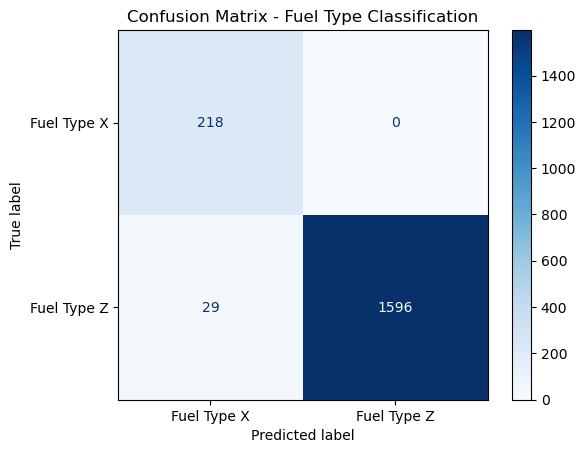

In [44]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fuel Type X', 'Fuel Type Z'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Fuel Type Classification")
plt.show()


**Classification Result**

The **Logistic Regression model** performed well in distinguishing vehicles by fuel type. It successfully captured the patterns between technical features and the type of fuel used.

**Fuel Type X** vehicles were commonly associated with lower CO₂ emissions, smaller engines, fewer cylinders, and manual transmissions.

**Fuel Type Z** vehicles showed higher CO₂ levels, larger engine capacity, more cylinders, and were more likely to use automatic transmissions.

This confirms the **predictive power** of these features, allowing for accurate identification of a vehicle’s fuel type using basic engine specifications.




**Conclusion**

Using Logistic Regression, the model achieved high accuracy in predicting a vehicle’s fuel type based on engine specifications and transmission. These results reinforce the findings from the earlier summary analytics and demonstrate that fuel type is strongly linked to measurable vehicle characteristics.

This supervised classification approach enhances our understanding of vehicle design and performance by:

- Allowing accurate fuel type prediction for unknown vehicles.
- Helping manufacturers understand design trends tied to fuel system choices.
- Supporting eco-labeling systems and emission-focused policies.

This confirms that machine learning classification can play a practical role in analyzing vehicle datasets where fuel characteristics are not explicitly labeled but can be inferred from other technical features.

## **🔚 Final Conclusion**
This project explored how machine learning and data analytics can be applied to vehicle data to classify and cluster car models based on their **carbon emissions, fuel consumption, and technical specifications**. Across all three phases, valuable insights were uncovered through both supervised and unsupervised learning methods:

1. **Emission Level Classification**
A **Random Forest** model successfully categorized cars into Low, Medium, and High CO₂ emission classes using engine size, fuel type, and transmission. Feature importance analysis revealed that engine size had the strongest influence on emissions, offering a reliable basis for emission forecasting and regulation.

2. **Clustering Based on Environmental Patterns**
Using **K-Means clustering**, car models were grouped into eco-friendly, moderate, and high-impact clusters based on average fuel consumption and CO₂ emissions. Despite the linear relationship between these features, clustering provided clear environmental categories, supporting targeted strategies for sustainability and emission control.

3. **Fuel Type Prediction via Classification**
A **Logistic Regression** model accurately predicted whether a vehicle used Fuel Type X or Z based on CO₂ emissions, engine specs, and transmission type. This showed that fuel type is highly correlated with technical design, enabling effective classification in datasets where the fuel label may be missing or unclear.

**🌍 Key Takeaways:**
- Engine size and fuel consumption are the most significant indicators of environmental impact.
- Clustering adds interpretability to continuous trends by grouping similar vehicles.
- Classification models can predict unseen or missing labels with high accuracy, supporting both regulatory and operational needs.

Overall, the integration of data preprocessing, statistical summary analytics, classification, clustering, and visualization provided a comprehensive view of how technical features relate to a vehicle’s carbon footprint. These findings can inform policy, consumer choice, and future research in sustainable transportation systems.

## **Video Presentation Link**
https://drive.google.com/drive/folders/1enwWyNhtfk8lB9jub-1u6GsZ4K8AqnJp?usp=sharing